# 06 - Final Results

Summary notebook: loads the final comparison, robustness, and configuration tables. The authoritative narrative document is `docs/final_validation_report.md`; this notebook is a visual companion to it, not a replacement.

In [1]:
import sys, json
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import Image, display, Markdown

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / "src"))
RESULTS = REPO_ROOT / "results"
DOCS = REPO_ROOT / "docs"
DATA = REPO_ROOT / "data" / "processed"


## Final controller comparison

In [2]:
pd.read_csv(RESULTS / 'tables' / '04_controller_comparison.csv')

,controller,energy_kwh_mean,energy_kwh_std,violation_pct,max_temp_c,mean_action_change,shield_interventions,n_episodes
0,fixed,17.925000,3.552714e-15,0.0,23.981045,0.002105,0.0,20
1,threshold,7.200000,8.881784e-16,0.0,24.350670,0.000000,0.0,20
2,pid,6.428951,1.184407e-02,0.0,24.951064,0.003350,0.0,20
3,mpc,7.921935,3.508847e-01,0.0,24.341614,0.164975,0.0,20
4,ppo_seed0,35.550000,7.105427e-15,0.0,23.981045,0.007368,0.0,20
5,ppo_seed1,35.550000,7.105427e-15,0.0,23.981045,0.007368,0.0,20
6,ppo_seed2,6.472092,3.448413e-03,0.0,25.845779,0.000209,0.0,20
7,mappo_seed0,19.153132,5.608782e-01,0.0,23.981045,0.019625,0.0,20
8,mappo_seed1,34.950985,1.687512e-01,0.0,23.981045,0.009464,0.0,20
9,mappo_seed2,35.550000,7.105427e-15,0.0,23.981045,0.007368,0.0,20


## Robustness (synthetic workload spike and forecast-noise experiments)

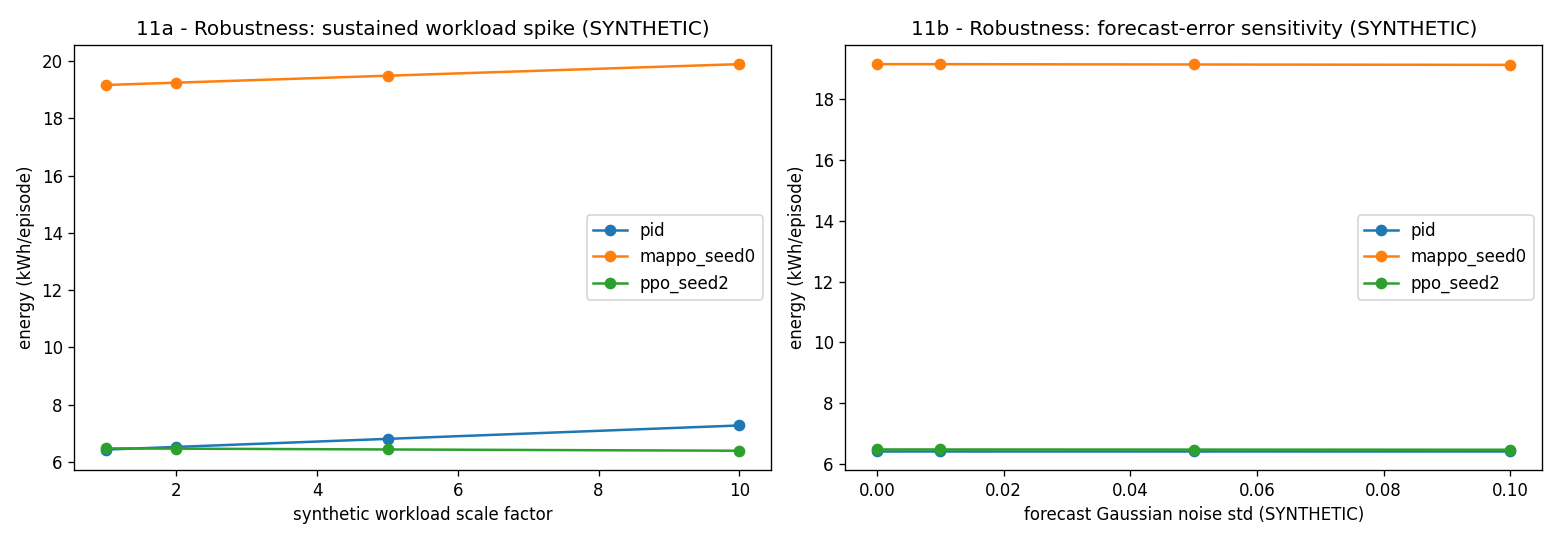

In [3]:
display(Image(filename=str(RESULTS / 'figures' / '11_robustness.png')))

In [4]:
pd.read_csv(RESULTS / 'tables' / '05_robustness_comparison.csv')

,experiment,condition,controller,energy,max_temp,viol_pct
0,B_workload_spike,scale_1.0,pid,6.429532,24.950185,0.0
1,B_workload_spike,scale_1.0,mappo_seed0,19.164052,23.980563,0.0
2,B_workload_spike,scale_1.0,ppo_seed2,6.472058,25.846828,0.0
3,B_workload_spike,scale_2.0,pid,6.523155,24.955295,0.0
4,B_workload_spike,scale_2.0,mappo_seed0,19.244889,23.981127,0.0
5,B_workload_spike,scale_2.0,ppo_seed2,6.462274,25.889880,0.0
6,B_workload_spike,scale_5.0,pid,6.804058,24.974411,0.0
7,B_workload_spike,scale_5.0,mappo_seed0,19.487547,23.982817,0.0
8,B_workload_spike,scale_5.0,ppo_seed2,6.433982,26.018702,0.0
9,B_workload_spike,scale_10.0,pid,7.272290,25.011177,0.0


## Experiment configuration used for all reported results

In [5]:
pd.read_csv(RESULTS / 'tables' / '08_experiment_configuration.csv')

,parameter,value
0,bin_seconds,900
1,n_zones,3
2,cluster_for_zones,all
3,train/val/test split,0.6/0.2/0.2
4,forecast horizon_steps,2
5,forecast lookback_steps,16
6,thermal_mass_kwh_per_c,0.5
7,cooling_max_kw,0.5
8,safety_limit_c,27.0
9,reward: energy_weight,1.0


## Conclusions, strictly from the evidence

See `docs/final_validation_report.md` S20 for the full research-question-by-research-question discussion. Headline: under this project's CPU-only compute budget, **classical PID outperformed both single-agent PPO and a from-scratch, bug-fixed MAPPO implementation on energy efficiency, while all controllers remained safe.** This is reported as the genuine finding, not adjusted to favor any method.